### 1) Mount Google Drive

In [1]:
# ============================================================
# SCC Histopathology Classification
# Model  : EfficientNet-B0
# Task   : 3-class grading (Well / Moderate / Poorly differentiated)
# Author : H.Amini
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2) Install required tools

In [ ]:
!pip install grad-cam -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 115.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
# ============================================================
# IMPORTS
# ============================================================

import os
import copy
import time
import pickle
from glob import glob

import numpy as np
import pandas as pd
from PIL import Image

import zipfile
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

import torchvision
from torchvision import transforms

from tqdm import tqdm

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    cohen_kappa_score,
    matthews_corrcoef,
)

import matplotlib.pyplot as plt
import seaborn as sns

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


###3) Set Parameters

In [ ]:
# ============================================================
# CONFIG
# ============================================================

MAIN_DIR       = "/content/drive/MyDrive/SCC"
ROOT_DIR       = "/content/sbmu-scc-davoudi"
CHECKPOINT_DIR = MAIN_DIR + "/EfficientNet_B0/checkpoints"

IMG_SIZE    = 224
BATCH_SIZE  = 16
NUM_EPOCHS  = 40
LR          = 3e-5
PATIENCE    = 8
NUM_CLASSES = 3
N_SPLITS    = 5
SEED        = 42

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [ ]:
# ============================================================
# DATA EXTRACTION
# ============================================================

zip_path    = MAIN_DIR + "/sbmu-scc-davoudi.zip"
extract_dir = "/content"

os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zf:
    for member in tqdm(zf.infolist(), desc="Extracting", unit="file"):
        zf.extract(member, extract_dir)

print("Extraction completed!")
print(os.listdir(extract_dir))

Extracting: 100%|██████████| 1566/1566 [03:01<00:00,  8.64file/s]

Extraction completed!
['.config', 'drive', 'sbmu-scc-davoudi', 'sample_data']


###4) Build Dataframe & Label Encoding

In [ ]:
# ============================================================
# BUILD DATAFRAME
# ============================================================

def build_dataframe(root_dir):
    rows = []

    class_names = sorted([
        d for d in os.listdir(root_dir)
        if os.path.isdir(os.path.join(root_dir, d))
    ])

    for class_name in class_names:
        class_path = os.path.join(root_dir, class_name)
        case_dirs  = sorted([
            d for d in os.listdir(class_path)
            if os.path.isdir(os.path.join(class_path, d))
        ])

        print("\n" + "=" * 50)
        print(f"CLASS: {class_name}")
        print("=" * 50)
        print(f"Number of Cases : {len(case_dirs)}")

        class_image_count = 0

        for case_folder_name in case_dirs:
            case_path   = os.path.join(class_path, case_folder_name)
            image_files = []

            for ext in ["*.jpg","*.JPG","*.jpeg","*.JPEG",
                        "*.png","*.PNG","*.tif","*.TIF","*.tiff","*.TIFF"]:
                image_files.extend(glob(os.path.join(case_path, ext)))

            image_files        = sorted(set(image_files))
            class_image_count += len(image_files)

            for img_path in image_files:
                rows.append({
                    "img_path"   : img_path,
                    "class_name" : class_name,
                    "case_id"    : f"{class_name}_{case_folder_name}"
                })

        print(f"Number of Images : {class_image_count}")

    return pd.DataFrame(rows), class_names


df, class_names = build_dataframe(ROOT_DIR)

print("\n" + "=" * 50)
print("DATAFRAME SUMMARY")
print("=" * 50)
print(df.head())
print(f"\nTotal Images : {len(df)}")
print(f"Total Cases  : {df['case_id'].nunique()}")


CLASS: moderately differentiated
Number of Cases : 85
Number of Images : 309

CLASS: poorly diffrentiated
Number of Cases : 45
Number of Images : 247

CLASS: well diffrentiated
Number of Cases : 229
Number of Images : 646

DATAFRAME SUMMARY
                                            img_path  \
0  /content/sbmu-scc-davoudi/moderately different...   
1  /content/sbmu-scc-davoudi/moderately different...   
2  /content/sbmu-scc-davoudi/moderately different...   
3  /content/sbmu-scc-davoudi/moderately different...   
4  /content/sbmu-scc-davoudi/moderately different...   

                  class_name                           case_id  
0  moderately differentiated  moderately differentiated_01-110  
1  moderately differentiated  moderately differentiated_01-110  
2  moderately differentiated  moderately differentiated_01-165  
3  moderately differentiated  moderately differentiated_01-165  
4  moderately differentiated  moderately differentiated_01-192  

Total Images : 1202
Total Case

In [ ]:
# Label encoding
label_mapping = {cls: idx for idx, cls in enumerate(class_names)}
df["label"]   = df["class_name"].map(label_mapping).astype(int)
print(f"\nLabel mapping: {label_mapping}")


Label mapping: {'moderately differentiated': 0, 'poorly diffrentiated': 1, 'well diffrentiated': 2}


###5) Augmentation

In [ ]:
# ============================================================
# TRANSFORMS
# ============================================================

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(90),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

###4) Dataset

In [ ]:
class HistologyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row   = self.dataframe.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, int(row["label"]), row["case_id"]

###5) Model

In [ ]:
def build_model(num_classes=3):
    weights             = torchvision.models.EfficientNet_B0_Weights.IMAGENET1K_V1
    model               = torchvision.models.efficientnet_b0(weights=weights)
    in_features         = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

###6) Training

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, epoch, num_epochs):
    model.train()
    running_loss = 0.0
    correct      = 0
    total        = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]", leave=False)

    for imgs, labels, _ in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds    = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        pbar.set_postfix({
            "loss": f"{running_loss/total:.4f}",
            "acc" : f"{correct/total:.4f}",
        })

    return running_loss / len(loader.dataset), correct / total


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, epoch, num_epochs):
    model.eval()
    running_loss = 0.0
    correct      = 0
    total        = 0

    pbar = tqdm(loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]  ", leave=False)

    for imgs, labels, _ in pbar:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        outputs = model(imgs)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * imgs.size(0)
        preds    = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

        pbar.set_postfix({
            "loss": f"{running_loss/total:.4f}",
            "acc" : f"{correct/total:.4f}",
        })

    return running_loss / len(loader.dataset), correct / total

###7) Predidtion Function

In [ ]:
@torch.no_grad()
def predict(model, loader):
    model.eval()
    records = []

    for images, labels, case_ids in loader:
        images       = images.to(DEVICE)
        outputs      = model(images)
        probabilities = torch.softmax(outputs, dim=1).cpu().numpy()
        labels        = labels.numpy()

        for prob, label, case_id in zip(probabilities, labels, case_ids):
            record = {"case_id": case_id, "y_true": int(label)}
            for i in range(prob.shape[0]):
                record[f"p{i}"] = float(prob[i])
            records.append(record)

    return pd.DataFrame(records)

###8) Case-Level Evaluation

In [ ]:
def evaluate_case_level(pred_df, class_names, plot_cm=False,
                         title="Confusion Matrix", verbose=True):
    n_classes = len(class_names)
    labels    = list(range(n_classes))
    prob_cols = [f"p{i}" for i in range(n_classes)]

    grouped_probs = pred_df.groupby("case_id")[prob_cols].mean()
    y_true        = pred_df.groupby("case_id")["y_true"].first().values
    y_pred        = grouped_probs.values.argmax(axis=1)

    acc             = accuracy_score(y_true, y_pred)
    bal_acc         = balanced_accuracy_score(y_true, y_pred)
    macro_precision = precision_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    macro_recall    = recall_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    macro_f1        = f1_score(y_true, y_pred, labels=labels, average="macro", zero_division=0)
    weighted_f1     = f1_score(y_true, y_pred, labels=labels, average="weighted", zero_division=0)
    kappa           = cohen_kappa_score(y_true, y_pred)
    mcc             = matthews_corrcoef(y_true, y_pred)
    cm              = confusion_matrix(y_true, y_pred, labels=labels)

    try:
        auc = roc_auc_score(y_true, grouped_probs.values, multi_class="ovr")
    except Exception:
        auc = None

    if verbose:
        print("\n" + "=" * 40)
        print("Evaluation Metrics")
        print("=" * 40)
        print(f"Accuracy           : {acc:.4f}")
        print(f"Balanced Accuracy  : {bal_acc:.4f}")
        print(f"Macro Precision    : {macro_precision:.4f}")
        print(f"Macro Recall       : {macro_recall:.4f}")
        print(f"Macro F1           : {macro_f1:.4f}")
        print(f"Weighted F1        : {weighted_f1:.4f}")
        print(f"Cohen Kappa        : {kappa:.4f}")
        print(f"MCC                : {mcc:.4f}")
        if auc is not None:
            print(f"ROC-AUC            : {auc:.4f}")
        print("\n" + "=" * 40)
        print("Classification Report")
        print("=" * 40)
        print(classification_report(
            y_true, y_pred, labels=labels,
            target_names=class_names, digits=4, zero_division=0
        ))

    if plot_cm:
        plt.figure(figsize=(6, 5))
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                    xticklabels=class_names, yticklabels=class_names)
        plt.xlabel("Predicted")
        plt.ylabel("True")
        plt.title(title)
        plt.tight_layout()
        plt.show()

    return {
        "accuracy": acc, "balanced_accuracy": bal_acc,
        "macro_precision": macro_precision, "macro_recall": macro_recall,
        "macro_f1": macro_f1, "weighted_f1": weighted_f1,
        "kappa": kappa, "mcc": mcc, "roc_auc": auc,
        "cm": cm, "y_true": y_true, "y_pred": y_pred
    }

###9) Stratified Group K-Fold


FOLD 1 / 5
Train : 287 cases | 966 images
Val   : 72 cases | 236 images
Train class counts:
 class_name
well diffrentiated           520
moderately differentiated    242
poorly diffrentiated         204
Name: count, dtype: int64
Val class counts:
 class_name
well diffrentiated           126
moderately differentiated     67
poorly diffrentiated          43
Name: count, dtype: int64
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 223MB/s]


Epoch [01/40] | 244.4s | Train Loss: 1.0565 | Train Acc: 0.4545 | Val Loss: 1.0551 | Val Acc: 0.4025 | Val Macro-F1: 0.3933 | LR: 3.00e-05 ★


Epoch [02/40] | 233.1s | Train Loss: 0.9464 | Train Acc: 0.5207 | Val Loss: 1.0437 | Val Acc: 0.4110 | Val Macro-F1: 0.3859 | LR: 2.98e-05


Epoch [03/40] | 231.8s | Train Loss: 0.8446 | Train Acc: 0.5807 | Val Loss: 0.9918 | Val Acc: 0.4958 | Val Macro-F1: 0.4740 | LR: 2.96e-05 ★


...

Epoch [17/40] | 231.2s | Train Loss: 0.5625 | Train Acc: 0.7516 | Val Loss: 0.7992 | Val Acc: 0.6229 | Val Macro-F1: 0.5807 | LR: 1.85e-05


Epoch [18/40] | 231.6s | Train Loss: 0.5552 | Train Acc: 0.7381 | Val Loss: 0.7956 | Val Acc: 0.6314 | Val Macro-F1: 0.6525 | LR: 1.74e-05


Epoch [19/40] | 231.4s | Train Loss: 0.5248 | Train Acc: 0.7505 | Val Loss: 0.7908 | Val Acc: 0.6441 | Val Macro-F1: 0.6433 | LR: 1.62e-05


Epoch [20/40] | 231.2s | Train Loss: 0.5260 | Train Acc: 0.7474 | Val Loss: 0.8025 | Val Acc: 0.6398 | Val Macro-F1: 0.6472 | LR: 1.51e-05


Epoch [21/40] | 230.4s | Train Loss: 0.5102 | Train Acc: 0.7743 | Val Loss: 0.7387 | Val Acc: 0.6568 | Val Macro-F1: 0.6712 | LR: 1.39e-05
Early stopping at epoch 21

Evaluation Metrics
Accuracy           : 0.7083
Balanced Accuracy  : 0.7164
Macro Precision    : 0.6466
Macro Recall       : 0.7164
Macro F1           : 0.6717
Weighted F1        : 0.7189
Cohen Kappa        : 0.4711
MCC                : 0.4785
ROC-AUC            : 0.8716

Classification Report
                           precision    recall  f1-score   support

moderately differentiated     0.4286    0.5294    0.4737        17
     poorly diffrentiated     0.6364    0.8750    0.7368         8
       well diffrentiated     0.8750    0.7447    0.8046        47

                 accuracy                         0.7083        72
                macro avg     0.6466    0.7164    0.6717        72
             weighted avg     0.7431    0.7083    0.7189        72



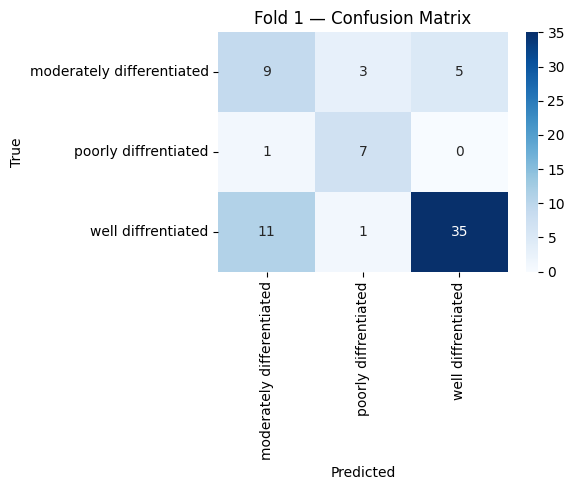

>>> Fold 1 checkpoint saved ✓


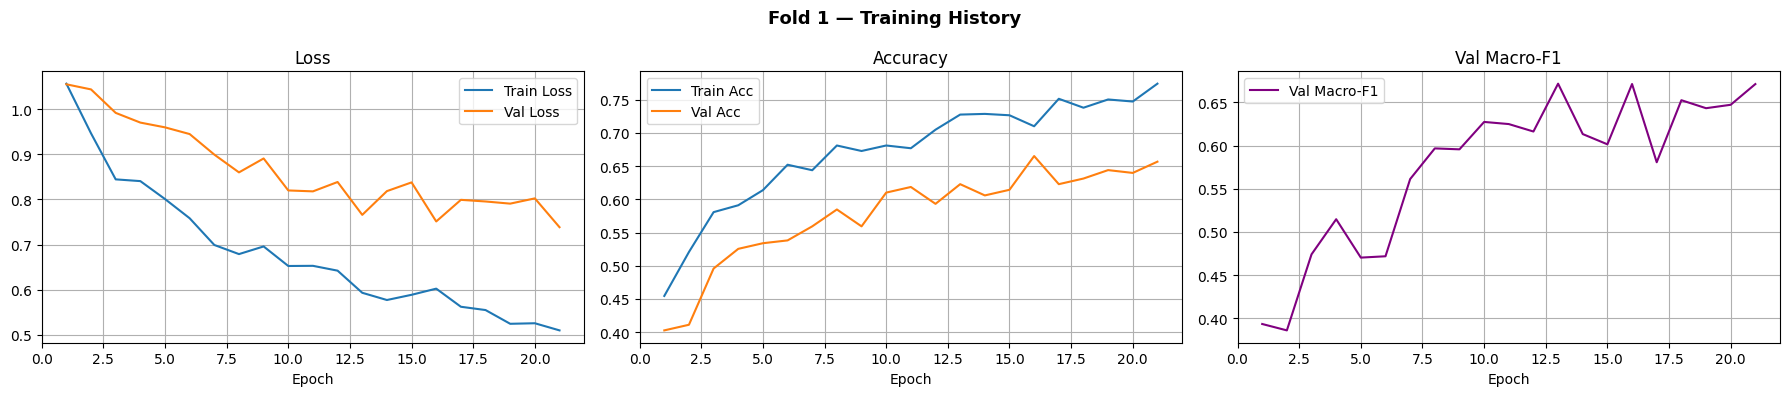


FOLD 2 / 5
Train : 288 cases | 964 images
Val   : 71 cases | 238 images
Train class counts:
 class_name
well diffrentiated           516
moderately differentiated    246
poorly diffrentiated         202
Name: count, dtype: int64
Val class counts:
 class_name
well diffrentiated           130
moderately differentiated     63
poorly diffrentiated          45
Name: count, dtype: int64


Epoch [01/40] | 232.2s | Train Loss: 1.0208 | Train Acc: 0.4564 | Val Loss: 1.0343 | Val Acc: 0.4412 | Val Macro-F1: 0.3837 | LR: 3.00e-05 ★


Epoch [02/40] | 230.6s | Train Loss: 0.9574 | Train Acc: 0.4710 | Val Loss: 0.9880 | Val Acc: 0.4874 | Val Macro-F1: 0.4798 | LR: 2.98e-05 ★


Epoch [03/40] | 228.2s | Train Loss: 0.8698 | Train Acc: 0.5425 | Val Loss: 0.9350 | Val Acc: 0.5714 | Val Macro-F1: 0.5949 | LR: 2.96e-05 ★


Epoch [04/40] | 229.6s | Train Loss: 0.8052 | Train Acc: 0.5778 | Val Loss: 0.9379 | Val Acc: 0.5672 | Val Macro-F1: 0.5758 | LR: 2.93e-05


...

Epoch [19/40] | 231.2s | Train Loss: 0.5027 | Train Acc: 0.7728 | Val Loss: 0.8601 | Val Acc: 0.6681 | Val Macro-F1: 0.7447 | LR: 1.62e-05


Epoch [20/40] | 229.1s | Train Loss: 0.5513 | Train Acc: 0.7479 | Val Loss: 0.8379 | Val Acc: 0.6723 | Val Macro-F1: 0.7346 | LR: 1.51e-05


Epoch [21/40] | 230.3s | Train Loss: 0.4888 | Train Acc: 0.7905 | Val Loss: 0.8210 | Val Acc: 0.6765 | Val Macro-F1: 0.7559 | LR: 1.39e-05


Epoch [22/40] | 232.0s | Train Loss: 0.5218 | Train Acc: 0.7521 | Val Loss: 0.8102 | Val Acc: 0.6849 | Val Macro-F1: 0.7033 | LR: 1.27e-05


Epoch [23/40] | 231.2s | Train Loss: 0.4845 | Train Acc: 0.7853 | Val Loss: 0.7844 | Val Acc: 0.6933 | Val Macro-F1: 0.7136 | LR: 1.16e-05
Early stopping at epoch 23

Evaluation Metrics
Accuracy           : 0.8028
Balanced Accuracy  : 0.8405
Macro Precision    : 0.7440
Macro Recall       : 0.8405
Macro F1           : 0.7712
Weighted F1        : 0.8154
Cohen Kappa        : 0.6568
MCC                : 0.6828
ROC-AUC            : 0.8916

Classification Report
                           precision    recall  f1-score   support

moderately differentiated     0.5652    0.8667    0.6842        15
     poorly diffrentiated     0.6667    0.8889    0.7619         9
       well diffrentiated     1.0000    0.7660    0.8675        47

                 accuracy                         0.8028        71
                macro avg     0.7440    0.8405    0.7712        71
             weighted avg     0.8659    0.8028    0.8154        71



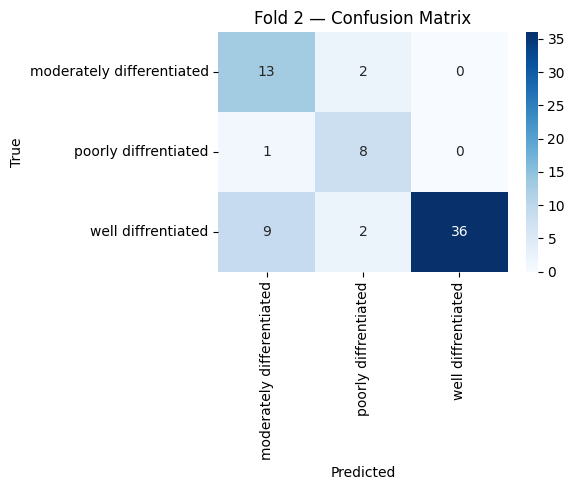

>>> Fold 2 checkpoint saved ✓


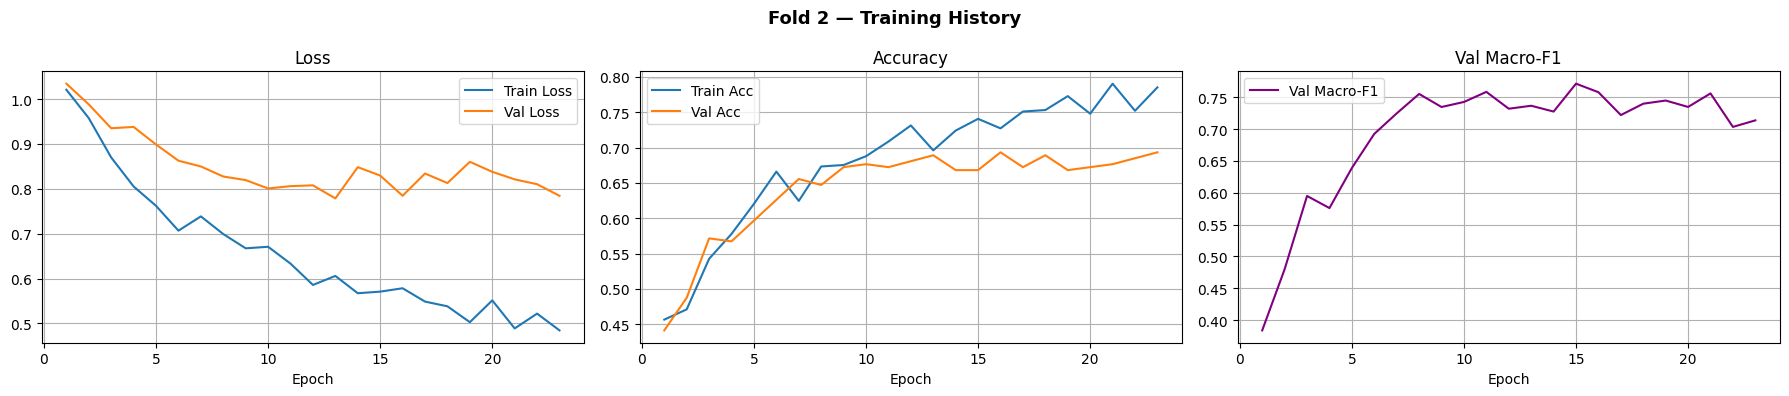


FOLD 3 / 5
Train : 287 cases | 958 images
Val   : 72 cases | 244 images
Train class counts:
 class_name
well diffrentiated           515
moderately differentiated    249
poorly diffrentiated         194
Name: count, dtype: int64
Val class counts:
 class_name
well diffrentiated           131
moderately differentiated     60
poorly diffrentiated          53
Name: count, dtype: int64


Epoch [01/40] | 232.8s | Train Loss: 1.0163 | Train Acc: 0.4749 | Val Loss: 1.0851 | Val Acc: 0.4180 | Val Macro-F1: 0.3662 | LR: 3.00e-05 ★


Epoch [02/40] | 234.0s | Train Loss: 0.9233 | Train Acc: 0.5084 | Val Loss: 1.0791 | Val Acc: 0.4344 | Val Macro-F1: 0.3850 | LR: 2.98e-05 ★


Epoch [03/40] | 232.4s | Train Loss: 0.8723 | Train Acc: 0.5355 | Val Loss: 1.0990 | Val Acc: 0.4221 | Val Macro-F1: 0.3785 | LR: 2.96e-05


Epoch [04/40] | 230.8s | Train Loss: 0.8295 | Train Acc: 0.5678 | Val Loss: 1.0246 | Val Acc: 0.4754 | Val Macro-F1: 0.4508 | LR: 2.93e-05 ★


...

Epoch [18/40] | 234.8s | Train Loss: 0.4851 | Train Acc: 0.7693 | Val Loss: 0.8819 | Val Acc: 0.6230 | Val Macro-F1: 0.5558 | LR: 1.74e-05


Epoch [19/40] | 235.5s | Train Loss: 0.5338 | Train Acc: 0.7557 | Val Loss: 0.8343 | Val Acc: 0.6434 | Val Macro-F1: 0.6141 | LR: 1.62e-05


Epoch [20/40] | 233.8s | Train Loss: 0.5054 | Train Acc: 0.7683 | Val Loss: 0.8312 | Val Acc: 0.6393 | Val Macro-F1: 0.5928 | LR: 1.51e-05


Epoch [21/40] | 235.1s | Train Loss: 0.4671 | Train Acc: 0.7756 | Val Loss: 0.7720 | Val Acc: 0.6885 | Val Macro-F1: 0.6486 | LR: 1.39e-05


Epoch [22/40] | 243.4s | Train Loss: 0.5059 | Train Acc: 0.7787 | Val Loss: 0.8035 | Val Acc: 0.6516 | Val Macro-F1: 0.6171 | LR: 1.27e-05
Early stopping at epoch 22

Evaluation Metrics
Accuracy           : 0.7361
Balanced Accuracy  : 0.6733
Macro Precision    : 0.6349
Macro Recall       : 0.6733
Macro F1           : 0.6486
Weighted F1        : 0.7430
Cohen Kappa        : 0.5220
MCC                : 0.5254
ROC-AUC            : 0.8418

Classification Report
                           precision    recall  f1-score   support

moderately differentiated     0.4667    0.4667    0.4667        15
     poorly diffrentiated     0.5333    0.7273    0.6154        11
       well diffrentiated     0.9048    0.8261    0.8636        46

                 accuracy                         0.7361        72
                macro avg     0.6349    0.6733    0.6486        72
             weighted avg     0.7567    0.7361    0.7430        72



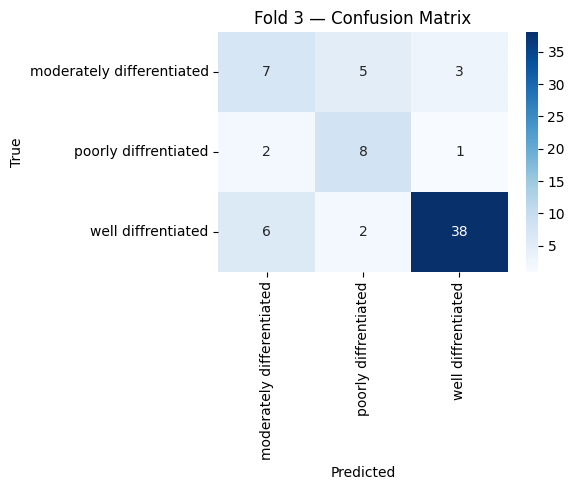

>>> Fold 3 checkpoint saved ✓


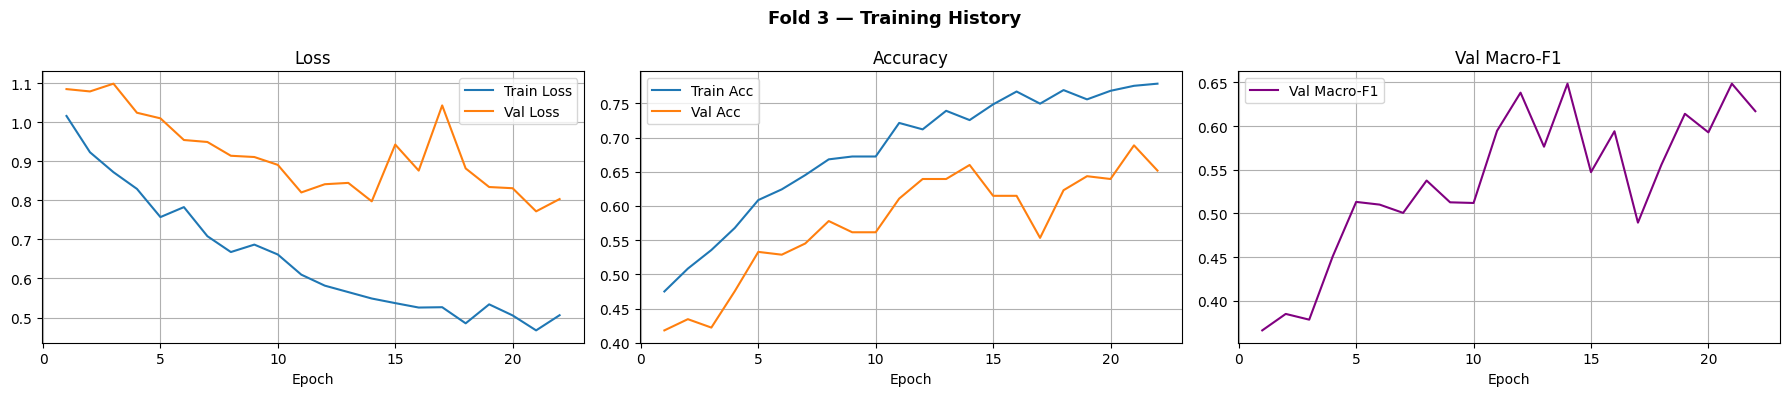


FOLD 4 / 5
Train : 287 cases | 959 images
Val   : 72 cases | 243 images
Train class counts:
 class_name
well diffrentiated           525
moderately differentiated    242
poorly diffrentiated         192
Name: count, dtype: int64
Val class counts:
 class_name
well diffrentiated           121
moderately differentiated     67
poorly diffrentiated          55
Name: count, dtype: int64


Epoch [01/40] | 231.8s | Train Loss: 1.0751 | Train Acc: 0.4327 | Val Loss: 1.0455 | Val Acc: 0.4609 | Val Macro-F1: 0.4127 | LR: 3.00e-05 ★


Epoch [02/40] | 236.6s | Train Loss: 0.9741 | Train Acc: 0.5214 | Val Loss: 1.0201 | Val Acc: 0.4527 | Val Macro-F1: 0.4202 | LR: 2.98e-05 ★


Epoch [03/40] | 238.7s | Train Loss: 0.8544 | Train Acc: 0.5829 | Val Loss: 0.9864 | Val Acc: 0.4403 | Val Macro-F1: 0.4307 | LR: 2.96e-05 ★


Epoch [04/40] | 239.2s | Train Loss: 0.8272 | Train Acc: 0.5662 | Val Loss: 0.9952 | Val Acc: 0.4733 | Val Macro-F1: 0.4414 | LR: 2.93e-05 ★


...

Epoch [16/40] | 231.6s | Train Loss: 0.5395 | Train Acc: 0.7581 | Val Loss: 0.8803 | Val Acc: 0.6337 | Val Macro-F1: 0.6169 | LR: 1.97e-05


Epoch [17/40] | 231.7s | Train Loss: 0.5311 | Train Acc: 0.7570 | Val Loss: 0.8655 | Val Acc: 0.6420 | Val Macro-F1: 0.6303 | LR: 1.85e-05


Epoch [18/40] | 233.6s | Train Loss: 0.5213 | Train Acc: 0.7591 | Val Loss: 0.8613 | Val Acc: 0.6461 | Val Macro-F1: 0.6320 | LR: 1.74e-05


Epoch [19/40] | 232.2s | Train Loss: 0.5054 | Train Acc: 0.7706 | Val Loss: 0.8768 | Val Acc: 0.6296 | Val Macro-F1: 0.6103 | LR: 1.62e-05


Epoch 20/40 [Train]:  70%|███████   | 42/60 [01:49<00:38,  2.12s/it, loss=0.4678, acc=0.7932]

In [ ]:
sgkf             = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_results     = []
oof_fold_records = []

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(df, y=df["label"], groups=df["case_id"]),
    start=1
):
    # Skip fold if checkpoint exists
    ckpt_file = os.path.join(CHECKPOINT_DIR, f"fold_{fold}_results.pkl")
    if os.path.exists(ckpt_file):
        print(f"\n>>> Fold {fold} already done — loading from checkpoint")
        with open(ckpt_file, "rb") as f:
            saved = pickle.load(f)
        fold_results.append(saved["metrics"])
        oof_fold_records.append(saved["pred_df"])
        continue

    print("\n" + "=" * 50)
    print(f"FOLD {fold} / {N_SPLITS}")
    print("=" * 50)

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    print(f"Train : {train_df['case_id'].nunique()} cases | {len(train_df)} images")
    print(f"Val   : {val_df['case_id'].nunique()} cases | {len(val_df)} images")
    print("Train class counts:\n", train_df["class_name"].value_counts())
    print("Val class counts:\n",   val_df["class_name"].value_counts())

    # ----- DataLoaders -----
    class_counts  = train_df["label"].value_counts().reindex(range(NUM_CLASSES), fill_value=1).sort_index()
    class_weights = torch.tensor(
        len(train_df) / (NUM_CLASSES * class_counts.values), dtype=torch.float32
    ).to(DEVICE)

    sample_weights = torch.DoubleTensor(
        train_df["label"].map(lambda x: 1.0 / class_counts.loc[x]).values
    )
    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )

    train_loader = DataLoader(
        HistologyDataset(train_df, transform=train_transforms),
        batch_size=BATCH_SIZE, sampler=sampler,
        num_workers=2, pin_memory=(DEVICE.type == "cuda")
    )
    val_loader = DataLoader(
        HistologyDataset(val_df, transform=val_transforms),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=(DEVICE.type == "cuda")
    )

    # ----- Model / Loss / Optimizer -----
    model     = build_model(NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=1e-7
    )

    best_f1            = -1
    best_model_weights = copy.deepcopy(model.state_dict())
    counter            = 0

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss"  : [], "val_acc"  : [],
        "val_macro_f1": [], "epoch_time": []
    }

    # ----- Epoch Loop -----
    for epoch in range(NUM_EPOCHS):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, epoch, NUM_EPOCHS
        )
        val_loss, val_acc = validate_one_epoch(
            model, val_loader, criterion, epoch, NUM_EPOCHS
        )

        pred_df     = predict(model, val_loader)
        val_metrics = evaluate_case_level(pred_df, class_names, plot_cm=False, verbose=False)

        scheduler.step()
        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["epoch_time"].append(epoch_time)

        marker = " ★" if val_metrics["macro_f1"] > best_f1 else ""
        print(
            f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | {epoch_time:.1f}s | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_metrics['macro_f1']:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}{marker}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1            = val_metrics["macro_f1"]
            best_model_weights = copy.deepcopy(model.state_dict())
            counter            = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # ----- Fold Evaluation -----
    model.load_state_dict(best_model_weights)
    final_pred_df = predict(model, val_loader)
    final_metrics = evaluate_case_level(
        final_pred_df, class_names,
        plot_cm=True, title=f"Fold {fold} — Confusion Matrix", verbose=True
    )

    fold_metric = {
        "fold"              : fold,
        "accuracy"          : final_metrics["accuracy"],
        "balanced_accuracy" : final_metrics["balanced_accuracy"],
        "macro_precision"   : final_metrics["macro_precision"],
        "macro_recall"      : final_metrics["macro_recall"],
        "macro_f1"          : final_metrics["macro_f1"],
        "weighted_f1"       : final_metrics["weighted_f1"],
        "kappa"             : final_metrics["kappa"],
        "mcc"               : final_metrics["mcc"],
        "roc_auc"           : final_metrics["roc_auc"]
    }
    fold_results.append(fold_metric)
    final_pred_df["fold"] = fold
    oof_fold_records.append(final_pred_df)

    # ----- Save Checkpoint -----
    with open(ckpt_file, "wb") as f:
        pickle.dump({"metrics": fold_metric, "pred_df": final_pred_df}, f)
    torch.save(
        best_model_weights,
        os.path.join(CHECKPOINT_DIR, f"fold_{fold}_weights.pth")
    )
    print(f">>> Fold {fold} checkpoint saved ✓")

    # ----- Training Curves -----
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Fold {fold} — Training History", fontsize=13, fontweight='bold')

    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True)

    axes[2].plot(epochs_range, history["val_macro_f1"], label="Val Macro-F1", color='purple')
    axes[2].set_title("Val Macro-F1"); axes[2].set_xlabel("Epoch")
    axes[2].legend(); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()


>>> Fold 1 already done — loading from checkpoint

>>> Fold 2 already done — loading from checkpoint

>>> Fold 3 already done — loading from checkpoint

FOLD 4 / 5
Train : 287 cases | 959 images
Val   : 72 cases | 243 images
Train class counts:
 class_name
well diffrentiated           525
moderately differentiated    242
poorly diffrentiated         192
Name: count, dtype: int64
Val class counts:
 class_name
well diffrentiated           121
moderately differentiated     67
poorly diffrentiated          55
Name: count, dtype: int64
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 171MB/s]


Epoch [01/40] | 238.6s | Train Loss: 1.0502 | Train Acc: 0.4745 | Val Loss: 1.0412 | Val Acc: 0.4115 | Val Macro-F1: 0.3537 | LR: 3.00e-05 ★


Epoch [02/40] | 235.9s | Train Loss: 0.9360 | Train Acc: 0.5235 | Val Loss: 1.0351 | Val Acc: 0.4074 | Val Macro-F1: 0.3210 | LR: 2.98e-05


Epoch [03/40] | 234.0s | Train Loss: 0.8445 | Train Acc: 0.5839 | Val Loss: 0.9714 | Val Acc: 0.4691 | Val Macro-F1: 0.4320 | LR: 2.96e-05 ★


...

Epoch [18/40] | 234.0s | Train Loss: 0.5215 | Train Acc: 0.7497 | Val Loss: 0.9176 | Val Acc: 0.6296 | Val Macro-F1: 0.6229 | LR: 1.74e-05


Epoch [19/40] | 234.2s | Train Loss: 0.5136 | Train Acc: 0.7685 | Val Loss: 0.9083 | Val Acc: 0.6296 | Val Macro-F1: 0.6062 | LR: 1.62e-05


Epoch [20/40] | 233.5s | Train Loss: 0.5419 | Train Acc: 0.7372 | Val Loss: 0.9028 | Val Acc: 0.6132 | Val Macro-F1: 0.6376 | LR: 1.51e-05


Epoch [21/40] | 234.3s | Train Loss: 0.4880 | Train Acc: 0.7685 | Val Loss: 0.8937 | Val Acc: 0.6420 | Val Macro-F1: 0.6240 | LR: 1.39e-05


Epoch [22/40] | 234.2s | Train Loss: 0.4981 | Train Acc: 0.7664 | Val Loss: 0.8888 | Val Acc: 0.6461 | Val Macro-F1: 0.5974 | LR: 1.27e-05
Early stopping at epoch 22

Evaluation Metrics
Accuracy           : 0.7083
Balanced Accuracy  : 0.6889
Macro Precision    : 0.6474
Macro Recall       : 0.6889
Macro F1           : 0.6577
Weighted F1        : 0.7238
Cohen Kappa        : 0.4985
MCC                : 0.5109
ROC-AUC            : 0.8389

Classification Report
                           precision    recall  f1-score   support

moderately differentiated     0.4800    0.6667    0.5581        18
     poorly diffrentiated     0.5455    0.6667    0.6000         9
       well diffrentiated     0.9167    0.7333    0.8148        45

                 accuracy                         0.7083        72
                macro avg     0.6474    0.6889    0.6577        72
             weighted avg     0.7611    0.7083    0.7238        72



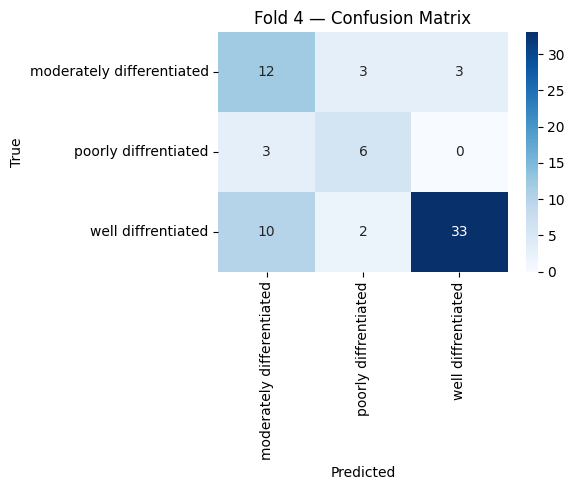

>>> Fold 4 checkpoint saved ✓


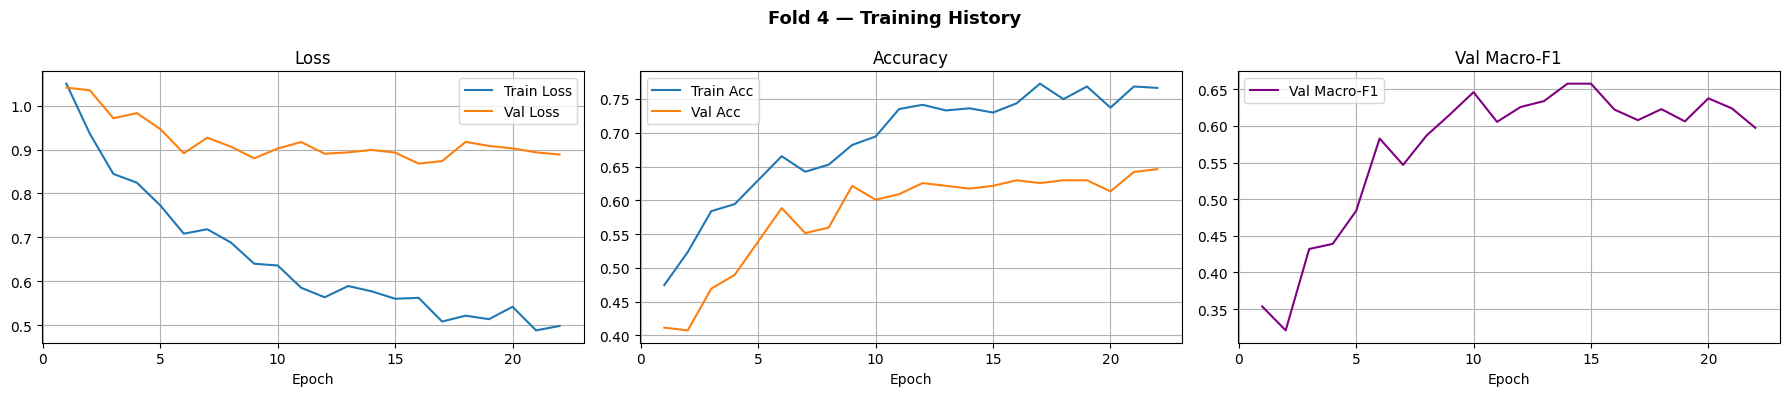


FOLD 5 / 5
Train : 287 cases | 961 images
Val   : 72 cases | 241 images
Train class counts:
 class_name
well diffrentiated           508
moderately differentiated    257
poorly diffrentiated         196
Name: count, dtype: int64
Val class counts:
 class_name
well diffrentiated           138
moderately differentiated     52
poorly diffrentiated          51
Name: count, dtype: int64


Epoch [01/40] | 236.3s | Train Loss: 1.0627 | Train Acc: 0.4069 | Val Loss: 1.0970 | Val Acc: 0.3527 | Val Macro-F1: 0.3664 | LR: 3.00e-05 ★


Epoch [02/40] | 235.4s | Train Loss: 0.9717 | Train Acc: 0.4870 | Val Loss: 1.0349 | Val Acc: 0.4232 | Val Macro-F1: 0.4363 | LR: 2.98e-05 ★


Epoch [03/40] | 235.6s | Train Loss: 0.8835 | Train Acc: 0.5172 | Val Loss: 1.0677 | Val Acc: 0.4066 | Val Macro-F1: 0.4136 | LR: 2.96e-05


Epoch [04/40] | 233.8s | Train Loss: 0.8337 | Train Acc: 0.5744 | Val Loss: 1.0060 | Val Acc: 0.4772 | Val Macro-F1: 0.4243 | LR: 2.93e-05


...

Epoch [25/40] | 233.0s | Train Loss: 0.5167 | Train Acc: 0.7721 | Val Loss: 0.8610 | Val Acc: 0.6224 | Val Macro-F1: 0.5716 | LR: 9.33e-06


Epoch [26/40] | 232.3s | Train Loss: 0.5015 | Train Acc: 0.7711 | Val Loss: 0.8341 | Val Acc: 0.6390 | Val Macro-F1: 0.5019 | LR: 8.26e-06


Epoch [27/40] | 233.8s | Train Loss: 0.4853 | Train Acc: 0.7794 | Val Loss: 0.9122 | Val Acc: 0.6183 | Val Macro-F1: 0.5883 | LR: 7.24e-06


Epoch [28/40] | 239.0s | Train Loss: 0.5018 | Train Acc: 0.7627 | Val Loss: 0.8567 | Val Acc: 0.6390 | Val Macro-F1: 0.5473 | LR: 6.26e-06


Epoch [29/40] | 236.1s | Train Loss: 0.5013 | Train Acc: 0.7586 | Val Loss: 0.8104 | Val Acc: 0.6639 | Val Macro-F1: 0.5358 | LR: 5.34e-06
Early stopping at epoch 29

Evaluation Metrics
Accuracy           : 0.6944
Balanced Accuracy  : 0.7174
Macro Precision    : 0.6333
Macro Recall       : 0.7174
Macro F1           : 0.6307
Weighted F1        : 0.7230
Cohen Kappa        : 0.5075
MCC                : 0.5336
ROC-AUC            : 0.8430

Classification Report
                           precision    recall  f1-score   support

moderately differentiated     0.5500    0.5500    0.5500        20
     poorly diffrentiated     0.3500    0.8750    0.5000         8
       well diffrentiated     1.0000    0.7273    0.8421        44

                 accuracy                         0.6944        72
                macro avg     0.6333    0.7174    0.6307        72
             weighted avg     0.8028    0.6944    0.7230        72



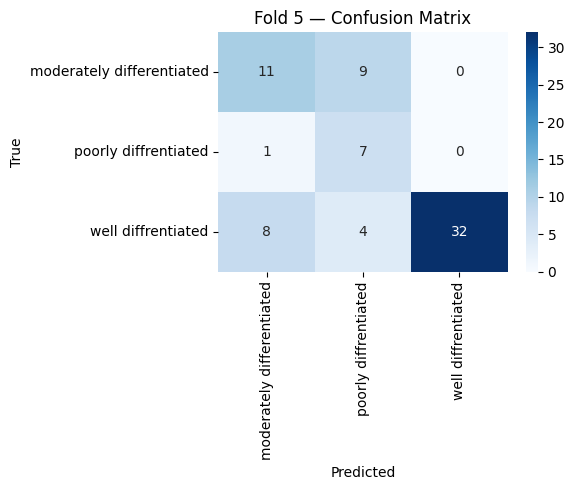

>>> Fold 5 checkpoint saved ✓


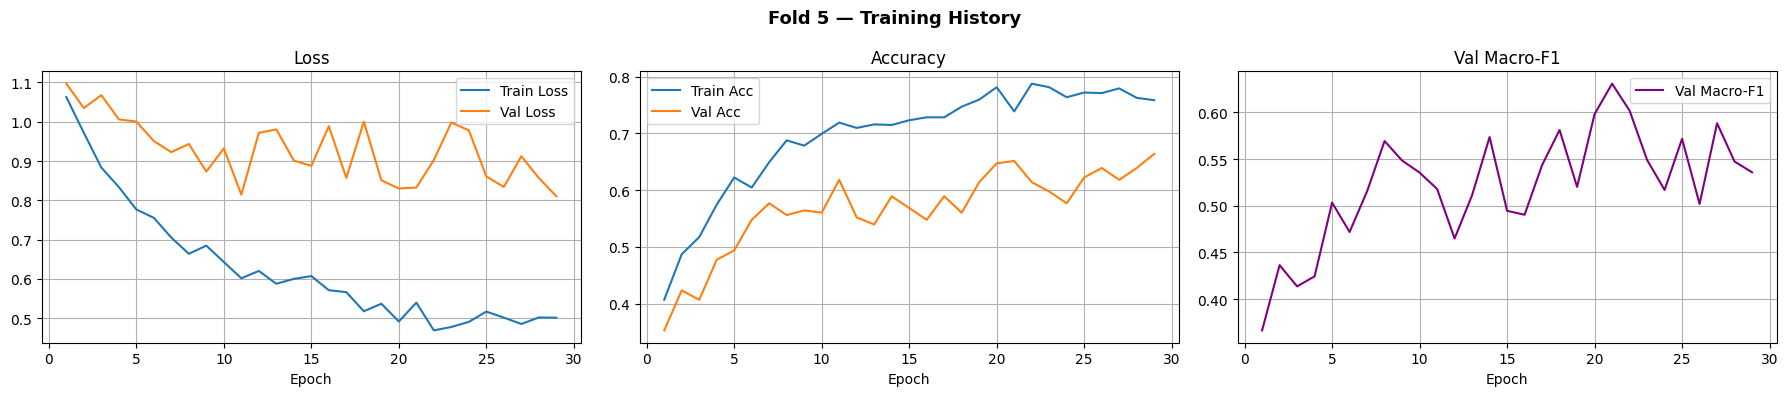

In [ ]:
sgkf             = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_results     = []
oof_fold_records = []

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(df, y=df["label"], groups=df["case_id"]),
    start=1
):
    # Skip fold if checkpoint exists
    ckpt_file = os.path.join(CHECKPOINT_DIR, f"fold_{fold}_results.pkl")
    if os.path.exists(ckpt_file):
        print(f"\n>>> Fold {fold} already done — loading from checkpoint")
        with open(ckpt_file, "rb") as f:
            saved = pickle.load(f)
        fold_results.append(saved["metrics"])
        oof_fold_records.append(saved["pred_df"])
        continue

    print("\n" + "=" * 50)
    print(f"FOLD {fold} / {N_SPLITS}")
    print("=" * 50)

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    print(f"Train : {train_df['case_id'].nunique()} cases | {len(train_df)} images")
    print(f"Val   : {val_df['case_id'].nunique()} cases | {len(val_df)} images")
    print("Train class counts:\n", train_df["class_name"].value_counts())
    print("Val class counts:\n",   val_df["class_name"].value_counts())

    # ----- DataLoaders -----
    class_counts  = train_df["label"].value_counts().reindex(range(NUM_CLASSES), fill_value=1).sort_index()
    class_weights = torch.tensor(
        len(train_df) / (NUM_CLASSES * class_counts.values), dtype=torch.float32
    ).to(DEVICE)

    sample_weights = torch.DoubleTensor(
        train_df["label"].map(lambda x: 1.0 / class_counts.loc[x]).values
    )
    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )

    train_loader = DataLoader(
        HistologyDataset(train_df, transform=train_transforms),
        batch_size=BATCH_SIZE, sampler=sampler,
        num_workers=2, pin_memory=(DEVICE.type == "cuda")
    )
    val_loader = DataLoader(
        HistologyDataset(val_df, transform=val_transforms),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=(DEVICE.type == "cuda")
    )

    # ----- Model / Loss / Optimizer -----
    model     = build_model(NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=1e-7
    )

    best_f1            = -1
    best_model_weights = copy.deepcopy(model.state_dict())
    counter            = 0

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss"  : [], "val_acc"  : [],
        "val_macro_f1": [], "epoch_time": []
    }

    # ----- Epoch Loop -----
    for epoch in range(NUM_EPOCHS):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, epoch, NUM_EPOCHS
        )
        val_loss, val_acc = validate_one_epoch(
            model, val_loader, criterion, epoch, NUM_EPOCHS
        )

        pred_df     = predict(model, val_loader)
        val_metrics = evaluate_case_level(pred_df, class_names, plot_cm=False, verbose=False)

        scheduler.step()
        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["epoch_time"].append(epoch_time)

        marker = " ★" if val_metrics["macro_f1"] > best_f1 else ""
        print(
            f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | {epoch_time:.1f}s | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_metrics['macro_f1']:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}{marker}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1            = val_metrics["macro_f1"]
            best_model_weights = copy.deepcopy(model.state_dict())
            counter            = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # ----- Fold Evaluation -----
    model.load_state_dict(best_model_weights)
    final_pred_df = predict(model, val_loader)
    final_metrics = evaluate_case_level(
        final_pred_df, class_names,
        plot_cm=True, title=f"Fold {fold} — Confusion Matrix", verbose=True
    )

    fold_metric = {
        "fold"              : fold,
        "accuracy"          : final_metrics["accuracy"],
        "balanced_accuracy" : final_metrics["balanced_accuracy"],
        "macro_precision"   : final_metrics["macro_precision"],
        "macro_recall"      : final_metrics["macro_recall"],
        "macro_f1"          : final_metrics["macro_f1"],
        "weighted_f1"       : final_metrics["weighted_f1"],
        "kappa"             : final_metrics["kappa"],
        "mcc"               : final_metrics["mcc"],
        "roc_auc"           : final_metrics["roc_auc"]
    }
    fold_results.append(fold_metric)
    final_pred_df["fold"] = fold
    oof_fold_records.append(final_pred_df)

    # ----- Save Checkpoint -----
    with open(ckpt_file, "wb") as f:
        pickle.dump({"metrics": fold_metric, "pred_df": final_pred_df}, f)
    torch.save(
        best_model_weights,
        os.path.join(CHECKPOINT_DIR, f"fold_{fold}_weights.pth")
    )
    print(f">>> Fold {fold} checkpoint saved ✓")

    # ----- Training Curves -----
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Fold {fold} — Training History", fontsize=13, fontweight='bold')

    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True)

    axes[2].plot(epochs_range, history["val_macro_f1"], label="Val Macro-F1", color='purple')
    axes[2].set_title("Val Macro-F1"); axes[2].set_xlabel("Epoch")
    axes[2].legend(); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()

In [ ]:
sgkf             = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
fold_results     = []
oof_fold_records = []

for fold, (train_idx, val_idx) in enumerate(
    sgkf.split(df, y=df["label"], groups=df["case_id"]),
    start=1
):
    # Skip fold if checkpoint exists
    ckpt_file = os.path.join(CHECKPOINT_DIR, f"fold_{fold}_results.pkl")
    if os.path.exists(ckpt_file):
        print(f"\n>>> Fold {fold} already done — loading from checkpoint")
        with open(ckpt_file, "rb") as f:
            saved = pickle.load(f)
        fold_results.append(saved["metrics"])
        oof_fold_records.append(saved["pred_df"])
        continue

    print("\n" + "=" * 50)
    print(f"FOLD {fold} / {N_SPLITS}")
    print("=" * 50)

    train_df = df.iloc[train_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    print(f"Train : {train_df['case_id'].nunique()} cases | {len(train_df)} images")
    print(f"Val   : {val_df['case_id'].nunique()} cases | {len(val_df)} images")
    print("Train class counts:\n", train_df["class_name"].value_counts())
    print("Val class counts:\n",   val_df["class_name"].value_counts())

    # ----- DataLoaders -----
    class_counts  = train_df["label"].value_counts().reindex(range(NUM_CLASSES), fill_value=1).sort_index()
    class_weights = torch.tensor(
        len(train_df) / (NUM_CLASSES * class_counts.values), dtype=torch.float32
    ).to(DEVICE)

    sample_weights = torch.DoubleTensor(
        train_df["label"].map(lambda x: 1.0 / class_counts.loc[x]).values
    )
    sampler = WeightedRandomSampler(
        weights=sample_weights, num_samples=len(sample_weights), replacement=True
    )

    train_loader = DataLoader(
        HistologyDataset(train_df, transform=train_transforms),
        batch_size=BATCH_SIZE, sampler=sampler,
        num_workers=2, pin_memory=(DEVICE.type == "cuda")
    )
    val_loader = DataLoader(
        HistologyDataset(val_df, transform=val_transforms),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=2, pin_memory=(DEVICE.type == "cuda")
    )

    # ----- Model / Loss / Optimizer -----
    model     = build_model(NUM_CLASSES).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=NUM_EPOCHS, eta_min=1e-7
    )

    best_f1            = -1
    best_model_weights = copy.deepcopy(model.state_dict())
    counter            = 0

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss"  : [], "val_acc"  : [],
        "val_macro_f1": [], "epoch_time": []
    }

    # ----- Epoch Loop -----
    for epoch in range(NUM_EPOCHS):
        epoch_start = time.time()

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, epoch, NUM_EPOCHS
        )
        val_loss, val_acc = validate_one_epoch(
            model, val_loader, criterion, epoch, NUM_EPOCHS
        )

        pred_df     = predict(model, val_loader)
        val_metrics = evaluate_case_level(pred_df, class_names, plot_cm=False, verbose=False)

        scheduler.step()
        epoch_time = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["val_macro_f1"].append(val_metrics["macro_f1"])
        history["epoch_time"].append(epoch_time)

        marker = " ★" if val_metrics["macro_f1"] > best_f1 else ""
        print(
            f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] | {epoch_time:.1f}s | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
            f"Val Macro-F1: {val_metrics['macro_f1']:.4f} | "
            f"LR: {optimizer.param_groups[0]['lr']:.2e}{marker}"
        )

        if val_metrics["macro_f1"] > best_f1:
            best_f1            = val_metrics["macro_f1"]
            best_model_weights = copy.deepcopy(model.state_dict())
            counter            = 0
        else:
            counter += 1
            if counter >= PATIENCE:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # ----- Fold Evaluation -----
    model.load_state_dict(best_model_weights)
    final_pred_df = predict(model, val_loader)
    final_metrics = evaluate_case_level(
        final_pred_df, class_names,
        plot_cm=True, title=f"Fold {fold} — Confusion Matrix", verbose=True
    )

    fold_metric = {
        "fold"              : fold,
        "accuracy"          : final_metrics["accuracy"],
        "balanced_accuracy" : final_metrics["balanced_accuracy"],
        "macro_precision"   : final_metrics["macro_precision"],
        "macro_recall"      : final_metrics["macro_recall"],
        "macro_f1"          : final_metrics["macro_f1"],
        "weighted_f1"       : final_metrics["weighted_f1"],
        "kappa"             : final_metrics["kappa"],
        "mcc"               : final_metrics["mcc"],
        "roc_auc"           : final_metrics["roc_auc"]
    }
    fold_results.append(fold_metric)
    final_pred_df["fold"] = fold
    oof_fold_records.append(final_pred_df)

    # ----- Save Checkpoint -----
    with open(ckpt_file, "wb") as f:
        pickle.dump({"metrics": fold_metric, "pred_df": final_pred_df}, f)
    torch.save(
        best_model_weights,
        os.path.join(CHECKPOINT_DIR, f"fold_{fold}_weights.pth")
    )
    print(f">>> Fold {fold} checkpoint saved ✓")

    # ----- Training Curves -----
    epochs_range = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Fold {fold} — Training History", fontsize=13, fontweight='bold')

    axes[0].plot(epochs_range, history["train_loss"], label="Train Loss")
    axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
    axes[0].legend(); axes[0].grid(True)

    axes[1].plot(epochs_range, history["train_acc"], label="Train Acc")
    axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc")
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch")
    axes[1].legend(); axes[1].grid(True)

    axes[2].plot(epochs_range, history["val_macro_f1"], label="Val Macro-F1", color='purple')
    axes[2].set_title("Val Macro-F1"); axes[2].set_xlabel("Epoch")
    axes[2].legend(); axes[2].grid(True)

    plt.tight_layout()
    plt.show()

    del model
    torch.cuda.empty_cache()


>>> Fold 1 already done — loading from checkpoint

>>> Fold 2 already done — loading from checkpoint

>>> Fold 3 already done — loading from checkpoint

>>> Fold 4 already done — loading from checkpoint

>>> Fold 5 already done — loading from checkpoint


###10) Final Cross Validation Results

In [ ]:
results_df   = pd.DataFrame(fold_results)
summary_cols = [
    "accuracy", "balanced_accuracy", "macro_precision", "macro_recall",
    "macro_f1", "weighted_f1", "kappa", "mcc", "roc_auc"
]

print("\n" + "=" * 50)
print("CROSS-VALIDATION RESULTS (Per Fold)")
print("=" * 50)
print(results_df.to_string(index=False))

print("\nMean ± Std:")
for col in summary_cols:
    print(f"  {col:>20}: {results_df[col].mean():.4f} ± {results_df[col].std():.4f}")


CROSS-VALIDATION RESULTS (Per Fold)
 fold  accuracy  balanced_accuracy  macro_precision  macro_recall  macro_f1  weighted_f1    kappa      mcc  roc_auc
    1  0.708333           0.716364         0.646645      0.716364  0.671708     0.718937 0.471144 0.478524 0.871600
    2  0.802817           0.840504         0.743961      0.840504  0.771195     0.815372 0.656768 0.682784 0.891641
    3  0.736111           0.673342         0.634921      0.673342  0.648563     0.743007 0.522013 0.525446 0.841759
    4  0.708333           0.688889         0.647374      0.688889  0.657651     0.723794 0.498507 0.510945 0.838859
    5  0.694444           0.717424         0.633333      0.717424  0.630702     0.722953 0.507463 0.533600 0.843031

Mean ± Std:
              accuracy: 0.7300 ± 0.0434
     balanced_accuracy: 0.7273 ± 0.0660
       macro_precision: 0.6612 ± 0.0467
          macro_recall: 0.7273 ± 0.0660
              macro_f1: 0.6760 ± 0.0553
           weighted_f1: 0.7448 ± 0.0405
              

###11) Global OOF Evaluation


GLOBAL OOF RESULTS

Evaluation Metrics
Accuracy           : 0.7298
Balanced Accuracy  : 0.7239
Macro Precision    : 0.6524
Macro Recall       : 0.7239
Macro F1           : 0.6735
Weighted F1        : 0.7444
Cohen Kappa        : 0.5316
MCC                : 0.5434
ROC-AUC            : 0.8585

Classification Report
                           precision    recall  f1-score   support

moderately differentiated     0.5000    0.6118    0.5503        85
     poorly diffrentiated     0.5217    0.8000    0.6316        45
       well diffrentiated     0.9355    0.7598    0.8386       229

                 accuracy                         0.7298       359
                macro avg     0.6524    0.7239    0.6735       359
             weighted avg     0.7805    0.7298    0.7444       359



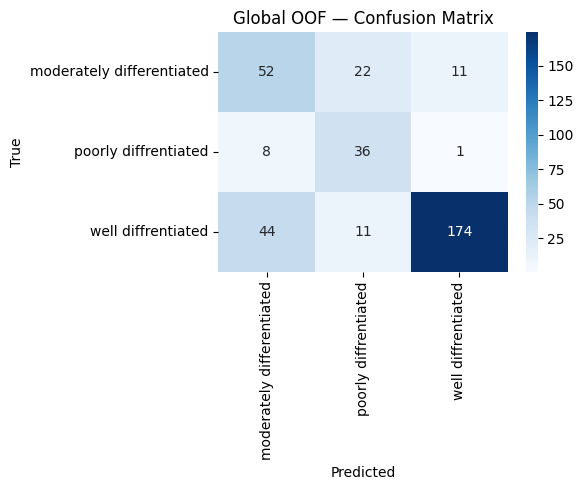

{'accuracy': 0.7298050139275766,
 'balanced_accuracy': np.float64(0.7238633444644234),
 'macro_precision': 0.6524076671341749,
 'macro_recall': 0.7238633444644234,
 'macro_f1': 0.6734659048334803,
 'weighted_f1': 0.7443522425256721,
 'kappa': np.float64(0.5315837615345296),
 'mcc': np.float64(0.5434307227427186),
 'roc_auc': np.float64(0.858537254946199),
 'cm': array([[ 52,  22,  11],
        [  8,  36,   1],
        [ 44,  11, 174]]),
 'y_true': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2,

In [ ]:
oof_df = pd.concat(oof_fold_records, axis=0).reset_index(drop=True)

print("\n" + "=" * 50)
print("GLOBAL OOF RESULTS")
print("=" * 50)

evaluate_case_level(
    oof_df, class_names,
    plot_cm=True, title="Global OOF — Confusion Matrix", verbose=True
)

###12) Ensemble Model


ENSEMBLE RESULTS
>>> Loading fold 1 model...
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 191MB/s]


>>> Loading fold 2 model...
>>> Loading fold 3 model...
>>> Loading fold 4 model...
>>> Loading fold 5 model...

Evaluation Metrics
Accuracy           : 0.8301
Balanced Accuracy  : 0.8683
Macro Precision    : 0.7769
Macro Recall       : 0.8683
Macro F1           : 0.8089
Weighted F1        : 0.8369
Cohen Kappa        : 0.7032
MCC                : 0.7174
ROC-AUC            : 0.9585

Classification Report
                           precision    recall  f1-score   support

moderately differentiated     0.6422    0.8235    0.7216        85
     poorly diffrentiated     0.7097    0.9778    0.8224        45
       well diffrentiated     0.9787    0.8035    0.8825       229

                 accuracy                         0.8301       359
                macro avg     0.7769    0.8683    0.8089       359
             weighted avg     0.8653    0.8301    0.8369       359



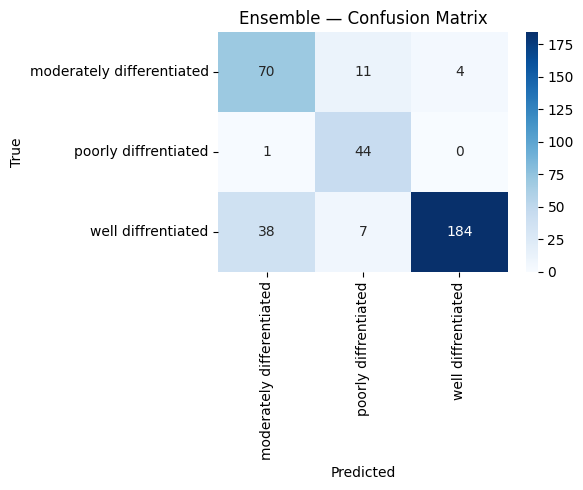

{'accuracy': 0.83008356545961,
 'balanced_accuracy': np.float64(0.8682668797747143),
 'macro_precision': 0.776867552824181,
 'macro_recall': 0.8682668797747143,
 'macro_f1': 0.8088577986247673,
 'weighted_f1': 0.8368821144241806,
 'kappa': np.float64(0.7031610052321956),
 'mcc': np.float64(0.7174349012835599),
 'roc_auc': np.float64(0.9585002173028844),
 'cm': array([[ 70,  11,   4],
        [  1,  44,   0],
        [ 38,   7, 184]]),
 'y_true': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2, 2, 2, 2

In [ ]:
# ============================================================
# ENSEMBLE EVALUATION
# All 5 fold models predict on ALL 324 cases → average probabilities
# ============================================================
print("\n" + "=" * 50)
print("ENSEMBLE RESULTS")
print("=" * 50)

# Full dataset loader
full_loader = DataLoader(
    HistologyDataset(df, transform=val_transforms),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=(DEVICE.type == "cuda")
)

ensemble_probs_list = []

for fold in range(1, N_SPLITS + 1):
    weights_path = os.path.join(CHECKPOINT_DIR, f"fold_{fold}_weights.pth")
    if not os.path.exists(weights_path):
        print(f">>> Fold {fold} weights not found — skipping")
        continue

    print(f">>> Loading fold {fold} model...")
    fold_model = build_model(NUM_CLASSES).to(DEVICE)
    fold_model.load_state_dict(torch.load(weights_path, map_location=DEVICE))

    fold_preds = predict(fold_model, full_loader)
    ensemble_probs_list.append(fold_preds)

    del fold_model
    torch.cuda.empty_cache()

# Average probabilities from all 5 models
prob_cols     = ["p0", "p1", "p2"]
all_probs     = pd.concat(ensemble_probs_list, axis=0).reset_index(drop=True)
ensemble_mean = all_probs.groupby("case_id")[prob_cols].mean().reset_index()
ensemble_true = all_probs.groupby("case_id")["y_true"].first().reset_index()
ensemble_eval_df = ensemble_mean.merge(ensemble_true, on="case_id")

evaluate_case_level(
    ensemble_eval_df, class_names,
    plot_cm=True, title="Ensemble — Confusion Matrix", verbose=True
)


  ENSEMBLE PREDICTION RESULT
  Image      : IMG_1666.JPG
  Prediction : moderately differentiated
  Confidence : 75.06%
---------------------------------------------
  Class Probabilities:
  moderately differentiated      : 75.06%  ██████████████████████
  poorly diffrentiated           :  3.31%  
  well diffrentiated             : 21.62%  ██████


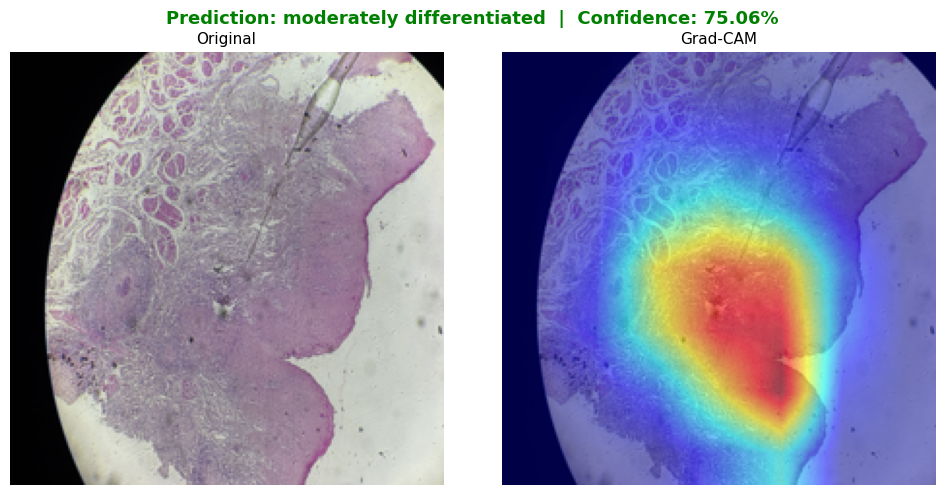

In [ ]:
# ============================================================
# ENSEMBLE INFERENCE — Single Image Prediction + Grad-CAM
# ============================================================

def ensemble_predict_image(image_path, class_names, checkpoint_dir, n_folds=5):
    """
    Takes a single image, returns ensemble prediction + Grad-CAM visualization.
    Grad-CAM is computed using the best fold model (highest confidence contributor).

    Args:
        image_path     : path to the input image
        class_names    : list of class names
        checkpoint_dir : directory containing fold_N_weights.pth files
        n_folds        : number of folds (default: 5)
    """

    # Load and preprocess image
    rgb_img = np.array(
        Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    ) / 255.0

    input_tensor = val_transforms(
        Image.fromarray((rgb_img * 255).astype(np.uint8))
    ).unsqueeze(0).to(DEVICE)

    # Collect probabilities from all fold models
    all_probs   = []
    best_model  = None
    best_prob   = -1

    for fold in range(1, n_folds + 1):
        weights_path = os.path.join(checkpoint_dir, f"fold_{fold}_weights.pth")
        if not os.path.exists(weights_path):
            print(f">>> Fold {fold} weights not found — skipping")
            continue

        model = build_model(NUM_CLASSES).to(DEVICE)
        model.load_state_dict(torch.load(weights_path, map_location=DEVICE))
        model.eval()

        with torch.no_grad():
            output = model(input_tensor)
            prob   = torch.softmax(output, dim=1).cpu().numpy()[0]
            all_probs.append(prob)

            # Keep model with highest max probability for Grad-CAM
            if prob.max() > best_prob:
                best_prob  = prob.max()
                best_model = model
            else:
                del model
                torch.cuda.empty_cache()

    # Average probabilities
    avg_probs  = np.mean(all_probs, axis=0)
    pred_idx   = avg_probs.argmax()
    pred_class = class_names[pred_idx]
    confidence = avg_probs[pred_idx] * 100

    # Print results
    print("\n" + "=" * 45)
    print("  ENSEMBLE PREDICTION RESULT")
    print("=" * 45)
    print(f"  Image      : {os.path.basename(image_path)}")
    print(f"  Prediction : {pred_class}")
    print(f"  Confidence : {confidence:.2f}%")
    print("-" * 45)
    print("  Class Probabilities:")
    for cls_name, prob in zip(class_names, avg_probs):
        bar = "█" * int(prob * 30)
        print(f"  {cls_name:<30} : {prob*100:5.2f}%  {bar}")
    print("=" * 45)

    # Grad-CAM with best fold model
    target_layers = [best_model.features[-1]]
    cam           = GradCAM(model=best_model, target_layers=target_layers)
    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(pred_idx)]
    )[0]
    visualization = show_cam_on_image(
        rgb_img.astype(np.float32), grayscale_cam, use_rgb=True
    )

    # Plot — Original | Grad-CAM
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    fig.suptitle(
        f"Prediction: {pred_class}  |  Confidence: {confidence:.2f}%",
        fontsize=13, fontweight='bold',
        color='green' if confidence >= 70 else 'orange'
    )

    axes[0].imshow(rgb_img)
    axes[0].set_title("Original", fontsize=11)
    axes[0].axis("off")

    axes[1].imshow(visualization)
    axes[1].set_title("Grad-CAM", fontsize=11)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    del best_model
    torch.cuda.empty_cache()

    return pred_class, confidence, avg_probs


# ---- Example Usage ----
# Replace with your image path
sample_image = df.iloc[0]["img_path"]

pred_class, confidence, probs = ensemble_predict_image(
    image_path     = sample_image,
    class_names    = class_names,
    checkpoint_dir = CHECKPOINT_DIR,
    n_folds        = N_SPLITS
)

###13) Grad-CAM


GRAD-CAM VISUALIZATION
>>> Best fold: 2  |  Macro-F1: 0.7712
>>> Weights loaded from fold 2


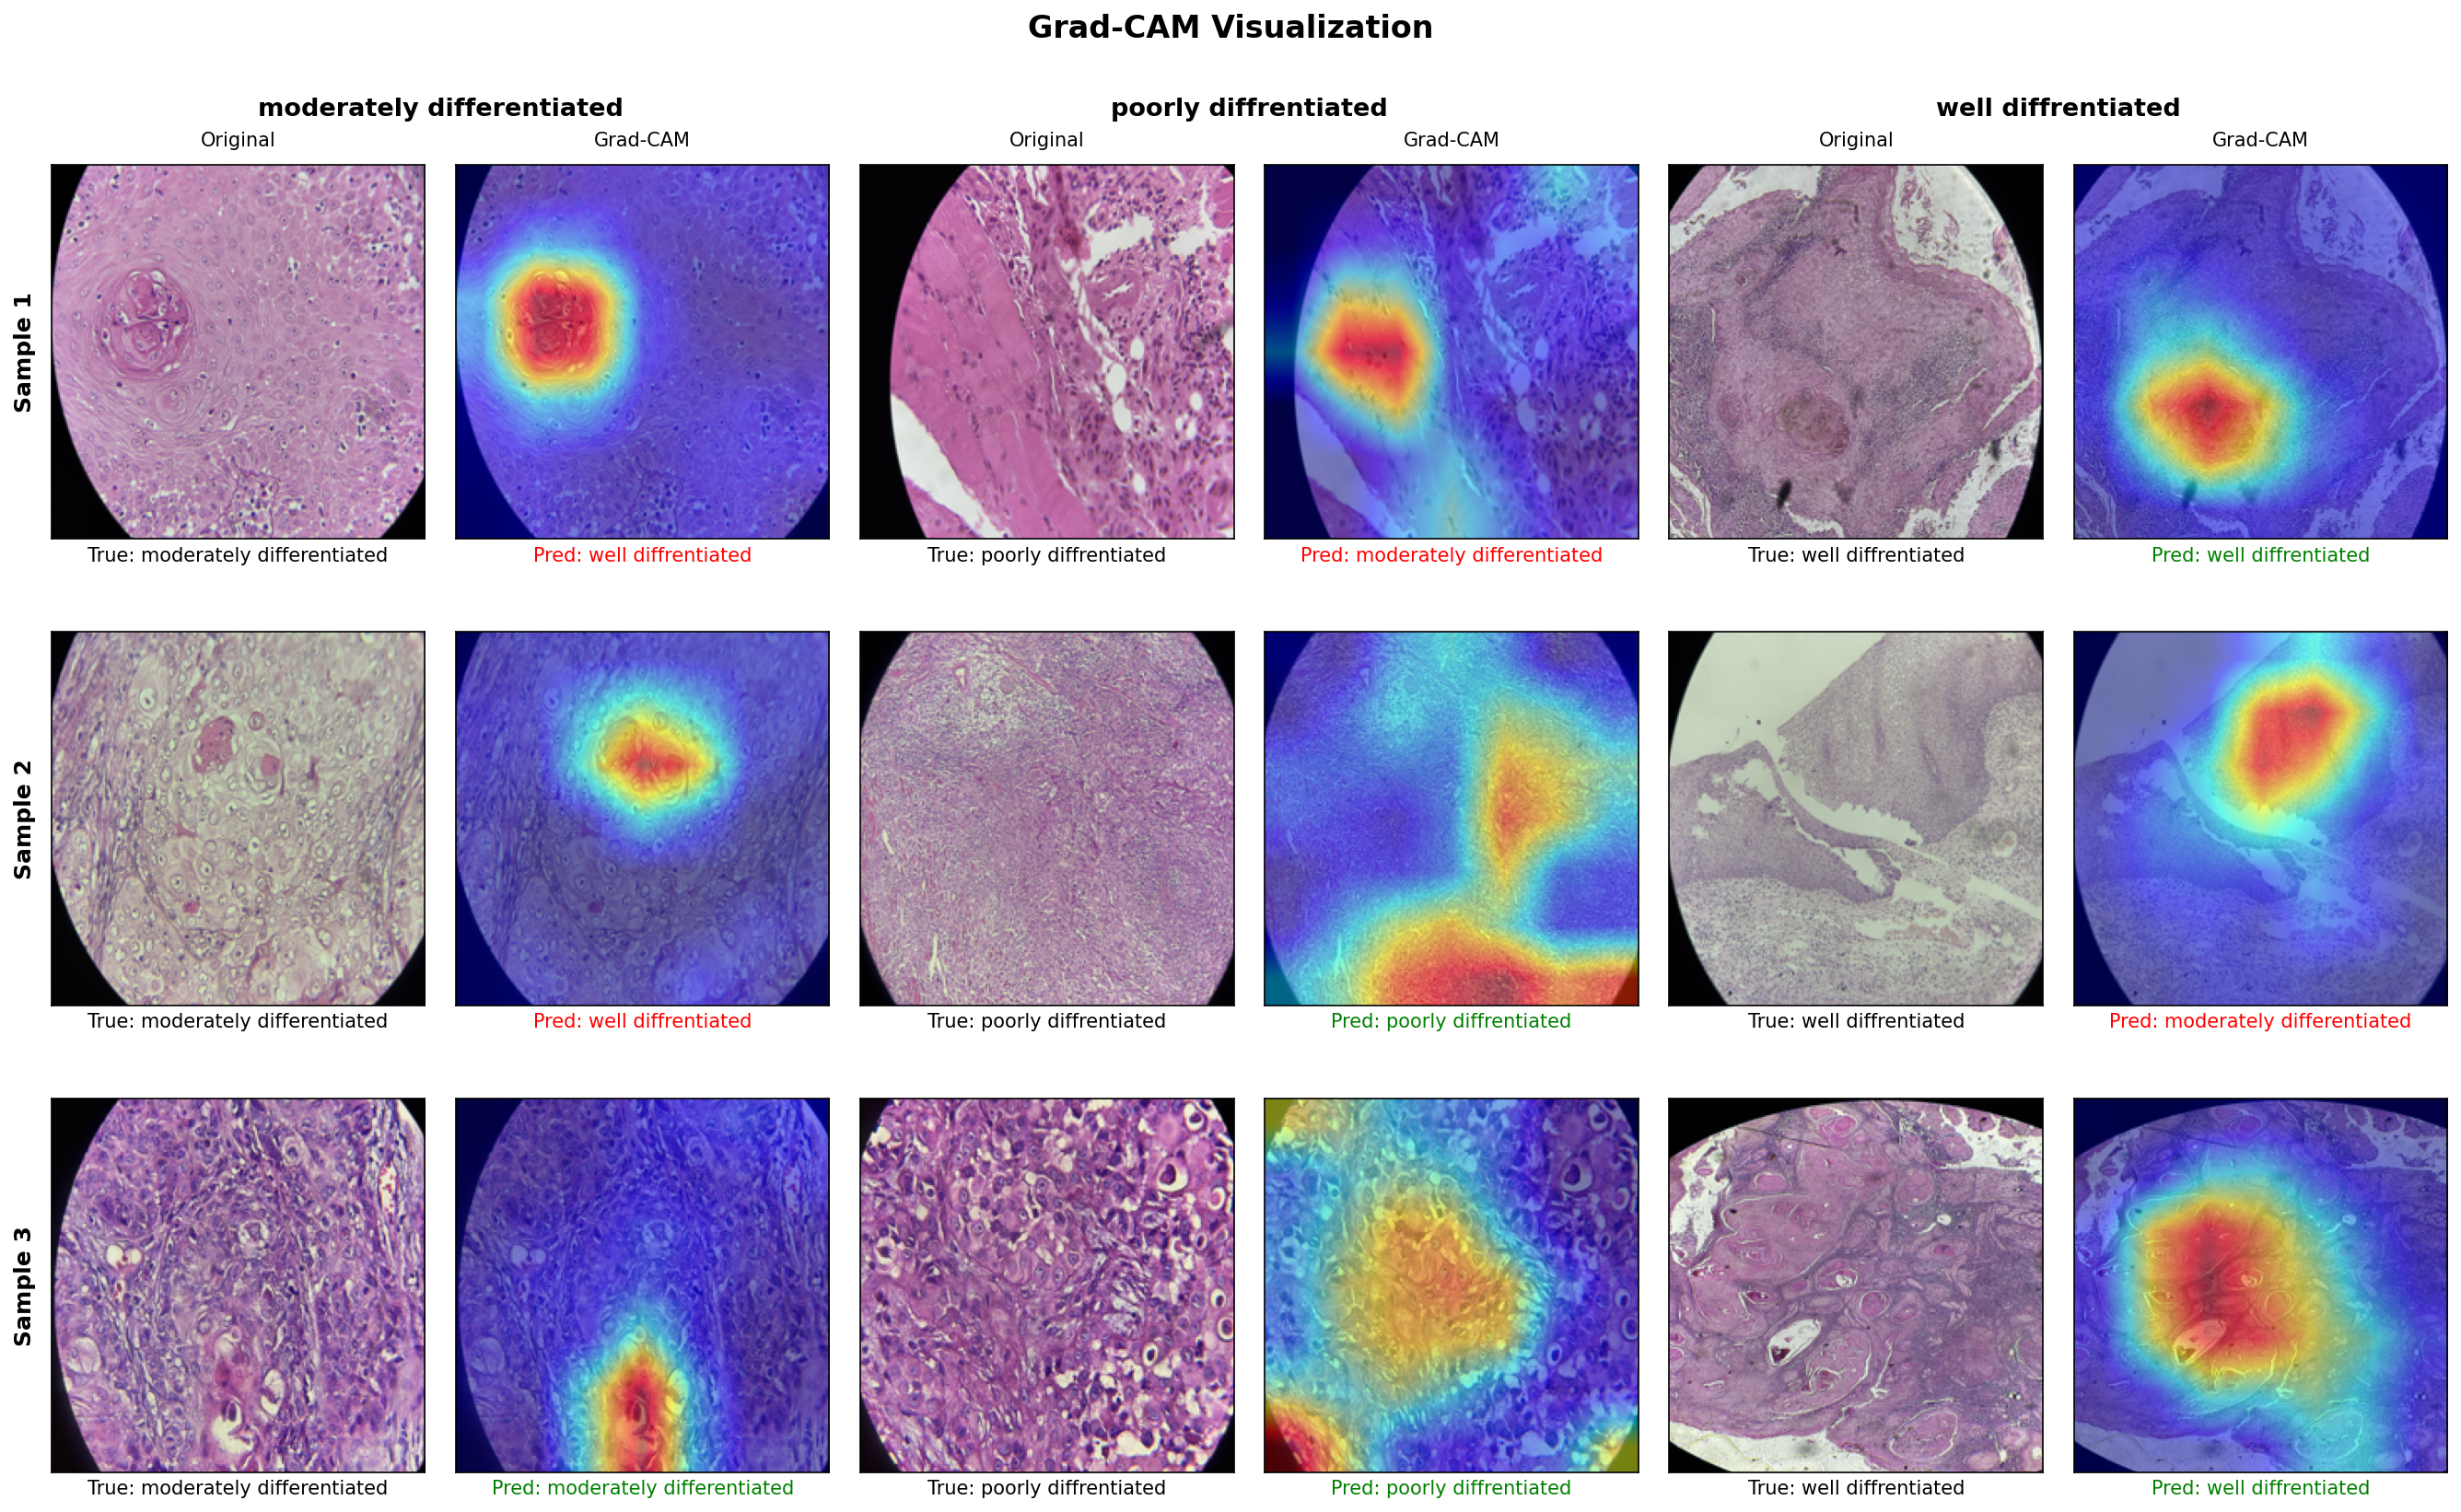

>>> Grad-CAM figure saved to /content/drive/MyDrive/SCC/EfficientNet_B0/checkpoints/gradcam_all_classes.png ✓


In [ ]:
print("\n" + "=" * 50)
print("GRAD-CAM VISUALIZATION")
print("=" * 50)

best_fold = max(fold_results, key=lambda x: x["macro_f1"])["fold"]
best_f1_v = max(fold_results, key=lambda x: x["macro_f1"])["macro_f1"]
print(f">>> Best fold: {best_fold}  |  Macro-F1: {best_f1_v:.4f}")

best_model = build_model(NUM_CLASSES).to(DEVICE)
best_model.load_state_dict(
    torch.load(os.path.join(CHECKPOINT_DIR, f"fold_{best_fold}_weights.pth"),
               map_location=DEVICE)
)
best_model.eval()
print(f">>> Weights loaded from fold {best_fold}")


def show_gradcam_all(model, df, class_names, n_samples=3):
    """
    Single figure grid: rows = samples, cols = class pairs (Original | Grad-CAM)
    Class name centered above each pair of columns.
    """
    model.eval()

    n_classes = len(class_names)
    n_cols    = n_classes * 2

    fig, axes = plt.subplots(
        n_samples, n_cols,
        figsize=(3 * n_cols, 3.5 * n_samples),
        dpi=150
    )
    fig.suptitle("Grad-CAM Visualization", fontsize=16, fontweight='bold', y=1.02)

    # Collect images and compute Grad-CAM
    all_data = {}
    for cls_idx, cls_name in enumerate(class_names):
        cls_images = df[df["label"] == cls_idx]["img_path"].values
        selected   = np.random.choice(cls_images, size=min(n_samples, len(cls_images)), replace=False)
        all_data[cls_idx] = []

        for image_path in selected:
            rgb_img = np.array(
                Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
            ) / 255.0

            input_tensor = val_transforms(
                Image.fromarray((rgb_img * 255).astype(np.uint8))
            ).unsqueeze(0).to(DEVICE)

            target_layers = [model.features[-1]]
            cam           = GradCAM(model=model, target_layers=target_layers)
            outputs       = model(input_tensor)
            pred_class    = outputs.argmax(dim=1).item()

            grayscale_cam = cam(
                input_tensor=input_tensor,
                targets=[ClassifierOutputTarget(pred_class)]
            )[0]
            visualization = show_cam_on_image(
                rgb_img.astype(np.float32), grayscale_cam, use_rgb=True
            )

            all_data[cls_idx].append({
                "rgb"    : rgb_img,
                "cam"    : visualization,
                "pred"   : pred_class,
                "correct": pred_class == cls_idx
            })

    # Plot
    for cls_idx, cls_name in enumerate(class_names):
        col = cls_idx * 2
        for row, item in enumerate(all_data[cls_idx]):

            # Row label on the left
            if cls_idx == 0:
                axes[row, 0].set_ylabel(
                    f"Sample {row+1}", fontsize=12, fontweight='bold', labelpad=8
                )

            # Original
            axes[row, col].imshow(item["rgb"])
            axes[row, col].set_xticks([]); axes[row, col].set_yticks([])
            axes[row, col].set_xlabel(f"True: {cls_name}", fontsize=10)

            # Grad-CAM
            axes[row, col+1].imshow(item["cam"])
            axes[row, col+1].set_xticks([]); axes[row, col+1].set_yticks([])
            axes[row, col+1].set_xlabel(
                f"Pred: {class_names[item['pred']]}",
                fontsize=10,
                color='green' if item["correct"] else 'red'
            )

            # Column headers on first row
            if row == 0:
                axes[0, col].set_title("Original",  fontsize=10, pad=10)
                axes[0, col+1].set_title("Grad-CAM", fontsize=10, pad=10)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.subplots_adjust(wspace=0.05, hspace=0.25)

    # Class name centered above each pair of columns (after tight_layout)
    for cls_idx, cls_name in enumerate(class_names):
        col   = cls_idx * 2
        pos_l = axes[0, col].get_position()
        pos_r = axes[0, col+1].get_position()
        fig.text(
            (pos_l.x0 + pos_r.x1) / 2,
            pos_l.y1 + 0.03,
            cls_name,
            ha='center', va='bottom',
            fontsize=13, fontweight='bold',
            transform=fig.transFigure
        )

    save_path = os.path.join(CHECKPOINT_DIR, "gradcam_all_classes.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f">>> Grad-CAM figure saved to {save_path} ✓")


show_gradcam_all(best_model, df, class_names, n_samples=3)